# Predicción municipal de rendimiento de café: resultado 2025 y validación cronológica

Este notebook explica y reproduce el resultado principal: **qué datos entraron al modelo, cómo se obtuvo la matriz de confusión de 2025 y por qué 89,36% de precisión ponderada no significa que el modelo cumpla MCC/Kappa de 0,85**.

La pregunta es: antes de iniciar el año `t`, ¿el rendimiento municipal de café quedará por encima del umbral histórico? El modelo es un prototipo académico explicable. Su estado riguroso sigue siendo `target_not_met`; no se presenta como apto para decisiones automáticas de producción.

In [1]:
from pathlib import Path
import json
import math
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_score,
)

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.annual_classifier import (
    CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    NUMERIC_FEATURES,
    ModelRecipe,
    annual_metrics,
    evaluate_final_holdout,
    walk_forward_backtest,
)
from src.evaluation.annual_pipeline import PRESENTATION_MODELS
from src.features.cafe_annual_features import audit_point_in_time

OUT = ROOT / "reports" / "modelo_mcc_kappa_cafe"
MART_PATH = ROOT / "data" / "processed" / "cafe_annual_model_mart.csv"
RETRAIN_MODELS = False
np.random.seed(42)
sns.set_theme(style="whitegrid")
assert OUT.is_dir() and MART_PATH.is_file()

mart = pd.read_csv(
    MART_PATH,
    dtype={"codigo_dane_municipio": str, "codigo_dane_departamento": str},
)
all_winner_predictions = pd.read_csv(
    OUT / "predicciones_modelo_seleccionado_2019_2025.csv",
    dtype={"codigo_dane_municipio": str, "codigo_dane_departamento": str},
)
manifest = json.loads((OUT / "model_manifest.json").read_text(encoding="utf-8"))
smote_balance = pd.read_csv(OUT / "balance_smotenc.csv")
print({"python": platform.python_version(), "semilla": 42, "reentrenar": RETRAIN_MODELS})

{'python': '3.12.10', 'semilla': 42, 'reentrenar': False}


## 1. Resultado central de 2025

El modelo **regresión logística L2 + SMOTENC** se ajustó con casos históricos elegibles anteriores a 2025. Después se compararon sus predicciones para 2025 con las clases reales de EVA 2025. Las etiquetas de 2025 no participaron en el ajuste, en la elección del algoritmo ni en la elección del umbral de decisión.

Aquí se recalculan las cifras desde el dataset y el archivo de predicciones; no se copian manualmente desde una tabla de resultados.

In [2]:
eligible_train = mart.loc[
    (mart.anio < 2025)
    & mart.rendimiento_t_ha.notna()
    & mart.rendimiento_lag_1.notna()
].copy()
holdout_2025_all = mart.loc[mart.anio == 2025].copy()
excluded_2025 = holdout_2025_all.loc[holdout_2025_all.rendimiento_lag_1.isna()].copy()
final_predictions = all_winner_predictions.loc[all_winner_predictions.anio == 2025].copy()

y_true_2025 = final_predictions.y_true.astype(int).to_numpy()
y_pred_2025 = final_predictions.y_pred.astype(int).to_numpy()
matrix_2025 = confusion_matrix(y_true_2025, y_pred_2025, labels=[0, 1])
tn, fp, fn, tp = (int(value) for value in matrix_2025.ravel())
n_2025 = int(matrix_2025.sum())
correct_2025 = int((y_true_2025 == y_pred_2025).sum())
incorrect_2025 = int(n_2025 - correct_2025)
accuracy_2025 = accuracy_score(y_true_2025, y_pred_2025)
weighted_precision_2025 = precision_score(
    y_true_2025, y_pred_2025, average="weighted", zero_division=0
)
mcc_2025 = matthews_corrcoef(y_true_2025, y_pred_2025)
kappa_2025 = cohen_kappa_score(y_true_2025, y_pred_2025)

precision_low_2025, precision_high_2025 = precision_score(
    y_true_2025, y_pred_2025, labels=[0, 1], average=None, zero_division=0
)
mcc_numerator = tp * tn - fp * fn
mcc_denominator = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
observed_agreement = (tn + tp) / n_2025
expected_agreement = (
    (tn + fp) * (tn + fn) + (fn + tp) * (fp + tp)
) / n_2025**2
kappa_manual = (observed_agreement - expected_agreement) / (1 - expected_agreement)

before = smote_balance.loc[smote_balance.etapa == "Antes"].set_index("clase").casos
after = smote_balance.loc[smote_balance.etapa == "Después"].set_index("clase").casos

summary_2025 = pd.DataFrame({
    "evidencia": [
        "Entrenamiento histórico elegible",
        "Filas EVA 2025 iniciales",
        "Filas excluidas por no tener rezago 2024",
        "Casos 2025 evaluados",
        "Aciertos / errores",
        "Accuracy",
        "Precisión ponderada WEKA",
        "MCC",
        "Kappa de Cohen",
    ],
    "resultado": [
        f"{len(eligible_train):,} ({eligible_train.anio.min()}-{eligible_train.anio.max()})",
        f"{len(holdout_2025_all):,}",
        f"{len(excluded_2025):,}",
        f"{n_2025:,}",
        f"{correct_2025} / {incorrect_2025}",
        f"{accuracy_2025:.6f}",
        f"{weighted_precision_2025:.6f}",
        f"{mcc_2025:.6f}",
        f"{kappa_2025:.6f}",
    ],
})
display(summary_2025)

print(f"{len(eligible_train):,} casos históricos elegibles ({eligible_train.anio.min()}-{eligible_train.anio.max()})")
print(f"{len(MODEL_FEATURES)} variables predictoras: {len(CATEGORICAL_FEATURES)} categóricas + {len(NUMERIC_FEATURES)} numéricas")
print(f"Balance antes de SMOTENC: Bajo={before['Bajo']:,}; Alto={before['Alto']:,}")
print(f"Balance después de SMOTENC: Bajo={after['Bajo']:,}; Alto={after['Alto']:,}")
print(f"2025: {len(holdout_2025_all):,} filas iniciales - {len(excluded_2025)} excluidas = {n_2025:,} casos evaluados")
print(f"Aciertos={correct_2025}; errores={incorrect_2025}; accuracy={accuracy_2025:.6f}")
print(f"MCC={mcc_numerator}/{mcc_denominator:.6f}={mcc_2025:.6f}")
print(f"Kappa=({observed_agreement:.6f}-{expected_agreement:.6f})/(1-{expected_agreement:.6f})={kappa_2025:.6f}")
print(f"Precisión WEKA ponderada={weighted_precision_2025:.6f} ({100 * weighted_precision_2025:.2f}%)")
print("0.73 no es 73% de accuracy: MCC y Kappa corrigen el efecto del desbalance y del acuerdo por azar.")

assert len(final_predictions) == len(holdout_2025_all) - len(excluded_2025)
assert set(final_predictions.train_max_year.astype(int)) == {2024}
assert np.isclose(mcc_numerator / mcc_denominator, mcc_2025)
assert np.isclose(kappa_manual, kappa_2025)

,evidencia,resultado
0,Entrenamiento histórico elegible,"10,270 (2008-2024)"
1,Filas EVA 2025 iniciales,640
2,Filas excluidas por no tener rezago 2024,4
3,Casos 2025 evaluados,636
4,Aciertos / errores,567 / 69
5,Accuracy,0.891509
6,Precisión ponderada WEKA,0.893607
7,MCC,0.730907
8,Kappa de Cohen,0.730456


10,270 casos históricos elegibles (2008-2024)
45 variables predictoras: 2 categóricas + 43 numéricas
Balance antes de SMOTENC: Bajo=4,471; Alto=5,799
Balance después de SMOTENC: Bajo=5,799; Alto=5,799
2025: 640 filas iniciales - 4 excluidas = 636 casos evaluados
Aciertos=567; errores=69; accuracy=0.891509
MCC=59462/81353.673377=0.730907
Kappa=(0.891509-0.597504)/(1-0.597504)=0.730456
Precisión WEKA ponderada=0.893607 (89.36%)
0.73 no es 73% de accuracy: MCC y Kappa corrigen el efecto del desbalance y del acuerdo por azar.


## 2. Datos con los que se entrenó

El ajuste final usa **10.270 observaciones municipio-año de 2008 a 2024**. La fuente cruda empieza en 2007, pero ese primer año no puede ser una fila de entrenamiento porque aún no existe `rendimiento_lag_1`. Los datos 2007-2018 también fijan el umbral histórico de la clase; eso es distinto de contar filas elegibles para ajustar el clasificador.

Las 45 entradas del modelo son 2 códigos geográficos categóricos y 43 variables numéricas históricas, geográficas y climáticas. El resultado real del mismo año nunca es una entrada.

In [3]:
training_by_year = eligible_train.groupby("anio").agg(
    casos=("codigo_dane_municipio", "size"),
    municipios=("codigo_dane_municipio", "nunique"),
    clase_baja=("rendimiento_alto", lambda values: int((values == 0).sum())),
    clase_alta=("rendimiento_alto", lambda values: int((values == 1).sum())),
)
feature_inventory = pd.DataFrame({
    "tipo": ["Categóricas", "Numéricas", "Total"],
    "cantidad": [len(CATEGORICAL_FEATURES), len(NUMERIC_FEATURES), len(MODEL_FEATURES)],
    "ejemplos": [
        ", ".join(CATEGORICAL_FEATURES),
        "rendimiento_lag_1, historiales móviles, clima t-1, latitud y longitud",
        "Entradas disponibles antes de conocer el rendimiento del año objetivo",
    ],
})
display(training_by_year)
display(feature_inventory)
print(f"Total comprobado: {training_by_year.casos.sum():,} filas; años efectivos: {training_by_year.index.min()}-{training_by_year.index.max()}")
print(f"Umbral fijo de clase: {manifest['target_threshold_t_ha']:.6f} t/ha, estimado con historia 2007-2018")

,casos,municipios,clase_baja,clase_alta
anio,,,,
2008,588,588,323,265
2009,591,591,356,235
2010,607,607,322,285
2011,613,613,396,217
2012,594,594,365,229
2013,566,566,419,147
2014,593,593,418,175
2015,595,595,127,468
2016,594,594,101,493


,tipo,cantidad,ejemplos
0,Categóricas,2,"codigo_dane_departamento, codigo_dane_municipio"
1,Numéricas,43,"rendimiento_lag_1, historiales móviles, clima ..."
2,Total,45,Entradas disponibles antes de conocer el rendi...


Total comprobado: 10,270 filas; años efectivos: 2008-2024
Umbral fijo de clase: 0.925852 t/ha, estimado con historia 2007-2018


## 3. Secuencia temporal que sí puede ejecutarse

El flujo es acumulativo: para evaluar un año `t`, se ajusta sólo con años `< t`. En 2025 se usaron resultados históricos hasta 2024, se transformó únicamente el bloque de entrenamiento con SMOTENC y luego se generó una predicción por cada municipio elegible de 2025.

SMOTENC es una técnica de balanceo, no el modelo. El clasificador final es una regresión logística con regularización L2 y umbral de probabilidad 0,55.

In [4]:
steps = [
    ("EVA 2007-2024", "Historia disponible"),
    ("Rezagos e históricos", "Sólo t-1 o anterior"),
    ("10.270 filas train", "Años 2008-2024"),
    ("SMOTENC en train", "4.471/5.799 → 5.799/5.799"),
    ("Logística L2", "Umbral 0,55"),
    ("636 casos 2025", "Comparación con EVA real"),
]
fig, ax = plt.subplots(figsize=(16, 3.2))
ax.set_xlim(-0.6, len(steps) - 0.4)
ax.set_ylim(-0.7, 0.8)
ax.axis("off")
for index, (title, subtitle) in enumerate(steps):
    ax.text(
        index, 0, f"{title}\n{subtitle}", ha="center", va="center", fontsize=9.5,
        bbox={"boxstyle": "round,pad=0.6", "facecolor": "#e8f3ed", "edgecolor": "#2e6b4f"},
    )
    if index < len(steps) - 1:
        ax.annotate("", xy=(index + 0.66, 0), xytext=(index + 0.40, 0),
                    arrowprops={"arrowstyle": "->", "color": "#2e6b4f", "lw": 1.8})
ax.set_title("Flujo reproducible del resultado 2025", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()
print("Regla auditada: para cada año t, train_max_year < t y feature_cutoff_year < t.")
print("En 2025: entrenamiento máximo=2024; las etiquetas EVA 2025 se usan sólo para medir el resultado.")

Regla auditada: para cada año t, train_max_year < t y feature_cutoff_year < t.
En 2025: entrenamiento máximo=2024; las etiquetas EVA 2025 se usan sólo para medir el resultado.


C:\Users\Visitante\AppData\Local\Temp\ipykernel_28468\902884939.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. De 640 filas de 2025 a 636 casos evaluados

EVA contiene 640 municipios cafeteros en 2025. Cuatro no tienen rendimiento municipal en 2024, por lo que no puede calcularse la entrada obligatoria `rendimiento_lag_1`. Se excluyen **antes** de predecir, bajo la misma regla de elegibilidad aplicada al entrenamiento.

Esto significa que los 567 aciertos se cuentan sobre 636 casos comparables, no sobre las 640 filas iniciales.

In [5]:
excluded_columns = [
    "codigo_dane_municipio", "municipio", "departamento",
    "rendimiento_t_ha", "rendimiento_lag_1",
]
excluded_view = excluded_2025[excluded_columns].rename(columns={
    "codigo_dane_municipio": "Código DIVIPOLA",
    "municipio": "Municipio",
    "departamento": "Departamento",
    "rendimiento_t_ha": "Rendimiento real 2025 (t/ha)",
    "rendimiento_lag_1": "Rendimiento 2024 requerido",
})
case_flow = pd.DataFrame({
    "paso": ["Filas café observadas en EVA 2025", "Sin lag de rendimiento 2024", "Casos evaluables"],
    "casos": [len(holdout_2025_all), -len(excluded_2025), len(final_predictions)],
})
display(case_flow)
display(excluded_view)
print(f"Comprobación aritmética: {len(holdout_2025_all)} - {len(excluded_2025)} = {len(final_predictions)}")

,paso,casos
0,Filas café observadas en EVA 2025,640
1,Sin lag de rendimiento 2024,-4
2,Casos evaluables,636


,Código DIVIPOLA,Municipio,Departamento,Rendimiento real 2025 (t/ha),Rendimiento 2024 requerido
227,05045,APARTADO,ANTIOQUIA,0.60,NaN
4178,23555,PLANETA RICA,CORDOBA,0.30,NaN
4179,23807,TIERRALTA,CORDOBA,0.75,NaN
8763,68132,CALIFORNIA,SANTANDER,1.00,NaN


Comprobación aritmética: 640 - 4 = 636


## 5. Matriz de confusión y cálculo de las métricas 2025

Las filas son la clase real y las columnas la predicción. `Bajo=0`, `Alto=1`; por tanto, la matriz es `[[TN, FP], [FN, TP]]`.

- 143 bajos fueron reconocidos como bajos (TN).
- 30 bajos fueron marcados erróneamente como altos (FP).
- 39 altos fueron marcados erróneamente como bajos (FN).
- 424 altos fueron reconocidos como altos (TP).

La precisión ponderada favorece el buen rendimiento en la clase alta, que representa 463 de 636 casos. MCC y Kappa penalizan más los errores y el acuerdo esperado por azar; por eso ambos quedan cerca de 0,73.

In [6]:
matrix_table = pd.DataFrame(
    matrix_2025,
    index=["Real bajo", "Real alto"],
    columns=["Predicho bajo", "Predicho alto"],
)
display(matrix_table)
fig, ax = plt.subplots(figsize=(5.6, 4.6))
sns.heatmap(matrix_table, annot=True, fmt="d", cmap="Greens", cbar=False, square=True, ax=ax)
ax.set_title("Matriz de confusión 2025 (n=636)")
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Resultado EVA real")
plt.tight_layout()
plt.show()

metric_math = pd.DataFrame({
    "métrica": ["Accuracy", "Precisión clase baja", "Precisión clase alta", "Precisión WEKA ponderada", "MCC", "Kappa"],
    "cálculo auditable": [
        f"({tn}+{tp})/{n_2025}",
        f"{tn}/({tn}+{fn})",
        f"{tp}/({tp}+{fp})",
        f"({tn + fp}×{precision_low_2025:.6f}+{fn + tp}×{precision_high_2025:.6f})/{n_2025}",
        f"({tp}×{tn}-{fp}×{fn})/{mcc_denominator:.6f}",
        f"({observed_agreement:.6f}-{expected_agreement:.6f})/(1-{expected_agreement:.6f})",
    ],
    "resultado": [accuracy_2025, precision_low_2025, precision_high_2025, weighted_precision_2025, mcc_2025, kappa_2025],
})
display(metric_math.style.format({"resultado": "{:.6f}"}))
print(f"Precisión baja: {tn}/({tn}+{fn})={precision_low_2025:.6f}")
print(f"Precisión alta: {tp}/({tp}+{fp})={precision_high_2025:.6f}")
print(f"Precisión ponderada: ({tn + fp}×{precision_low_2025:.6f}+{fn + tp}×{precision_high_2025:.6f})/{n_2025}={weighted_precision_2025:.6f}")

,Predicho bajo,Predicho alto
Real bajo,143,30
Real alto,39,424


C:\Users\Visitante\AppData\Local\Temp\ipykernel_28468\125766165.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,métrica,cálculo auditable,resultado
0,Accuracy,(143+424)/636,0.891509
1,Precisión clase baja,143/(143+39),0.785714
2,Precisión clase alta,424/(424+30),0.933921
3,Precisión WEKA ponderada,(173×0.785714+463×0.933921)/636,0.893607
4,MCC,(424×143-30×39)/81353.673377,0.730907
5,Kappa,(0.891509-0.597504)/(1-0.597504),0.730456


Precisión baja: 143/(143+39)=0.785714
Precisión alta: 424/(424+30)=0.933921
Precisión ponderada: (173×0.785714+463×0.933921)/636=0.893607


## 6. Estado inicial: cobertura, distribución, nulos y balance

Estas gráficas se calculan antes de modelar. El recorte p99 de la distribución y el boxplot es sólo visual; no elimina observaciones del entrenamiento.

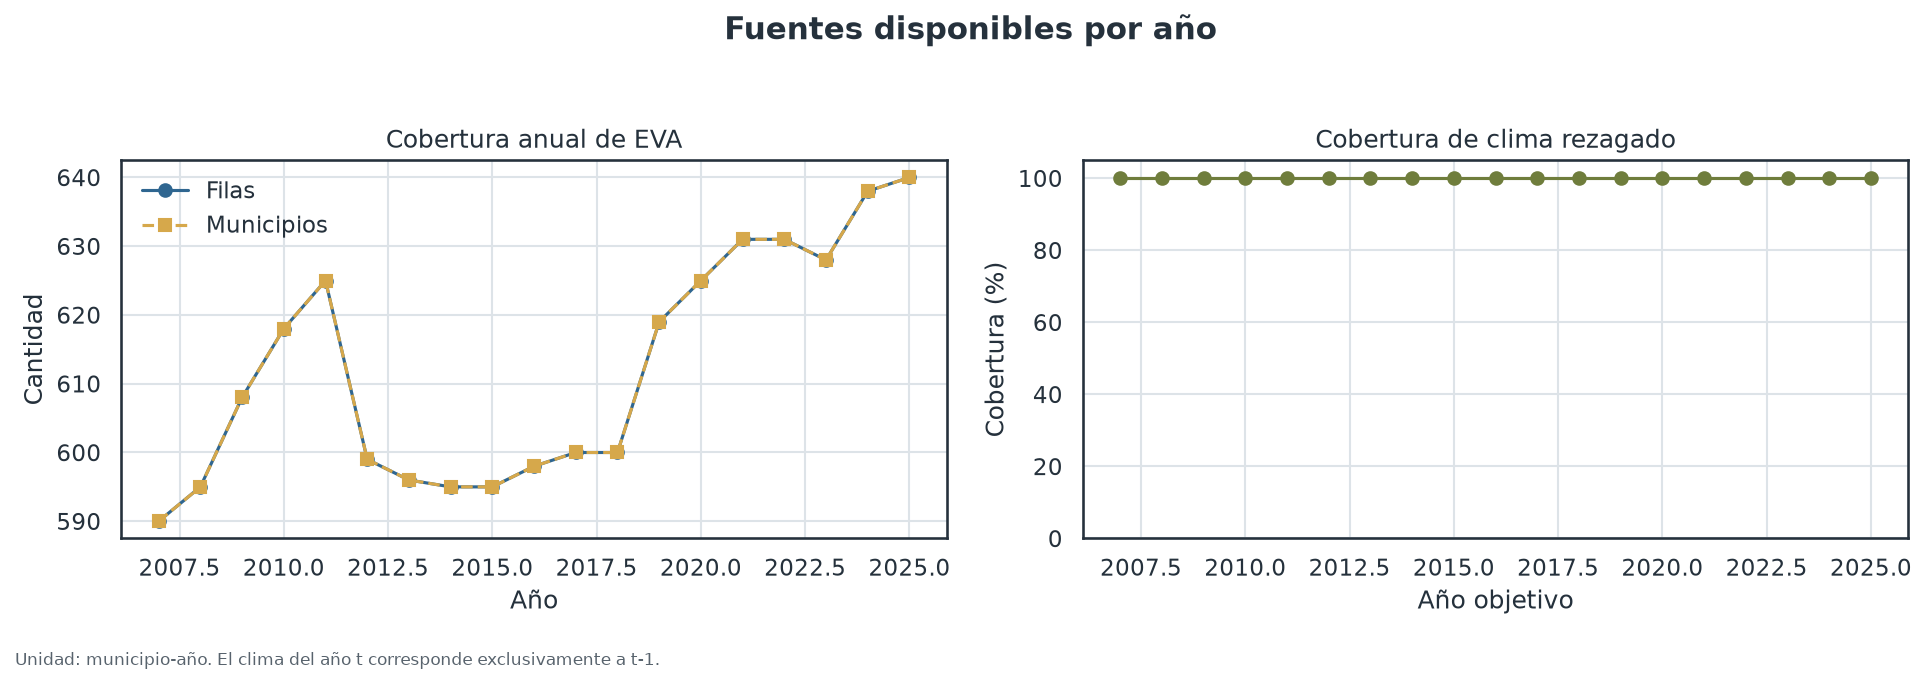

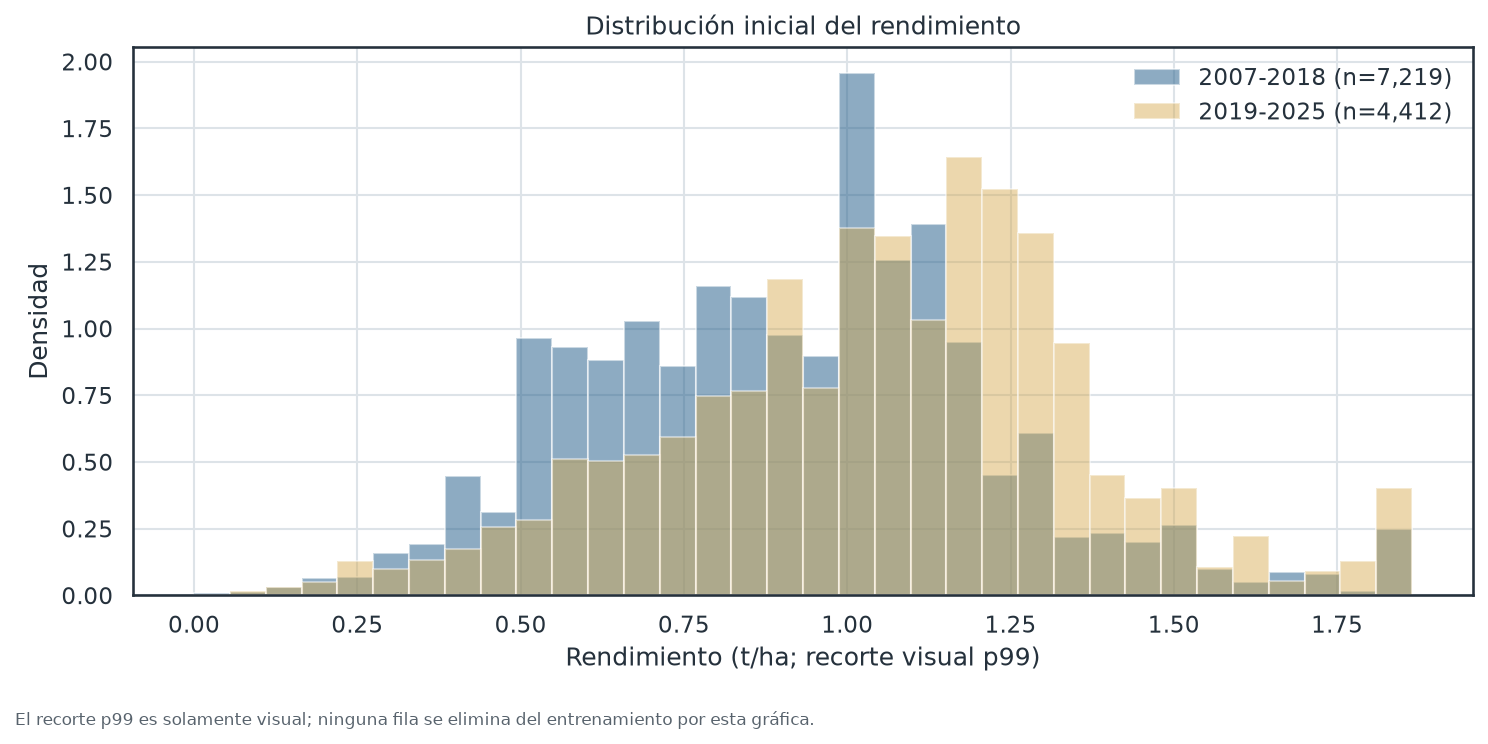

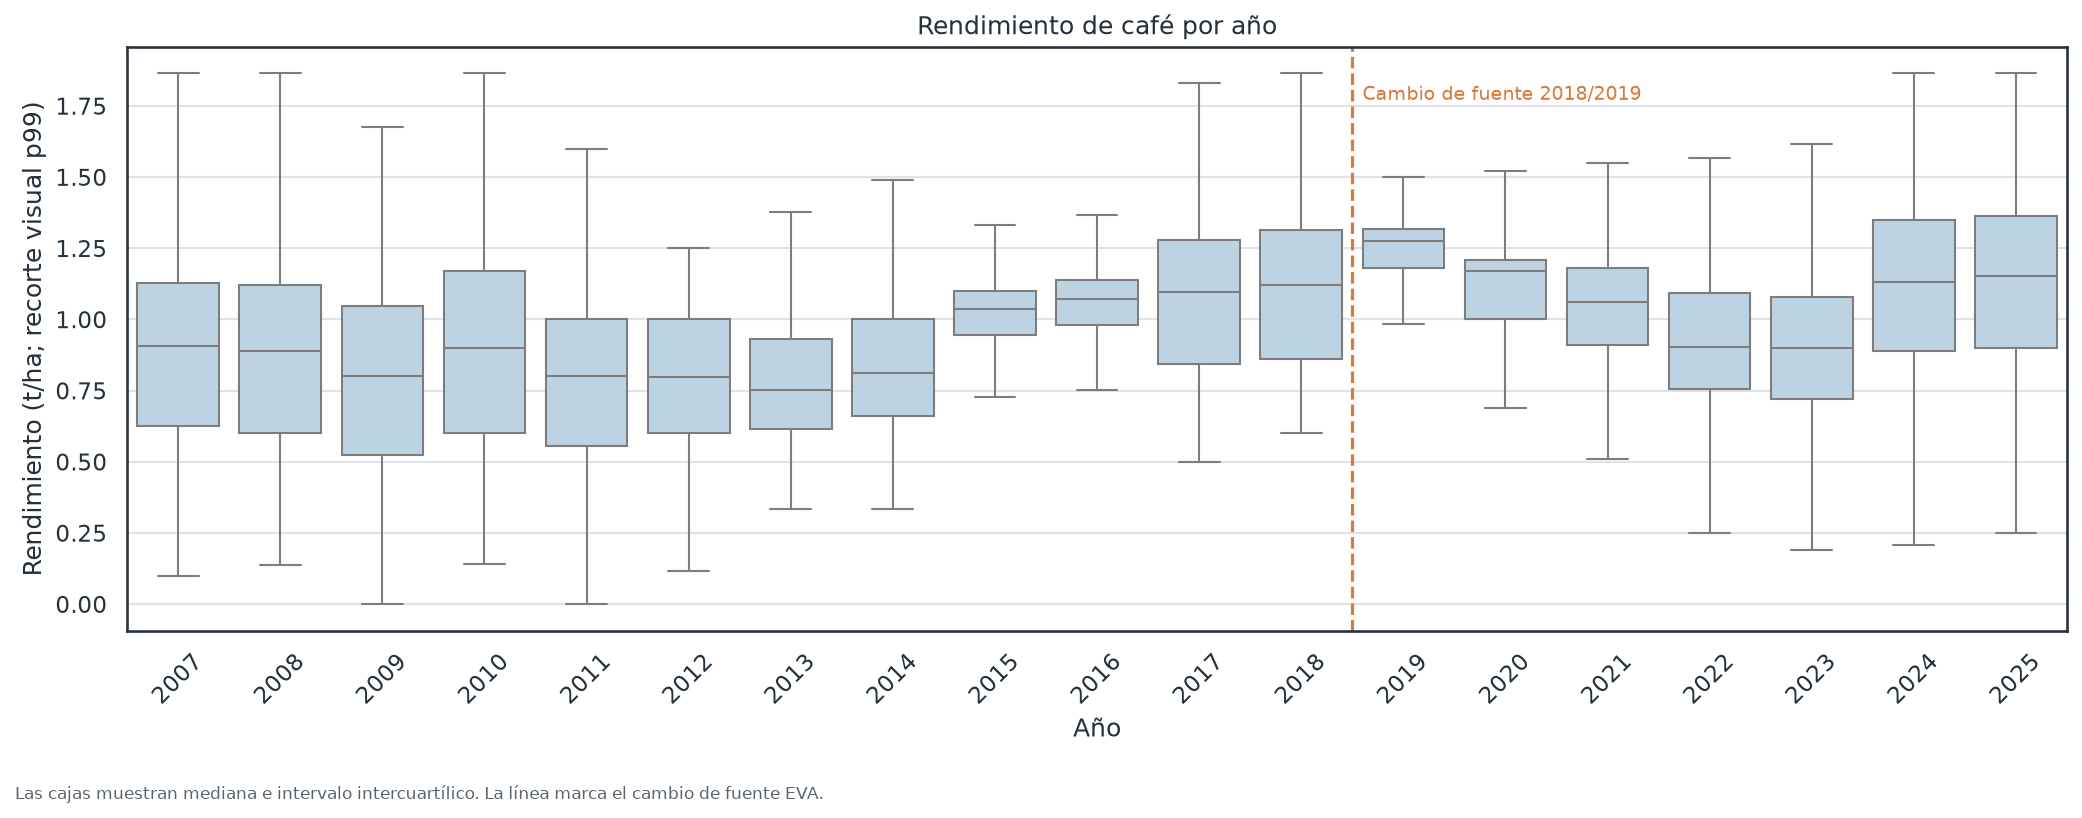

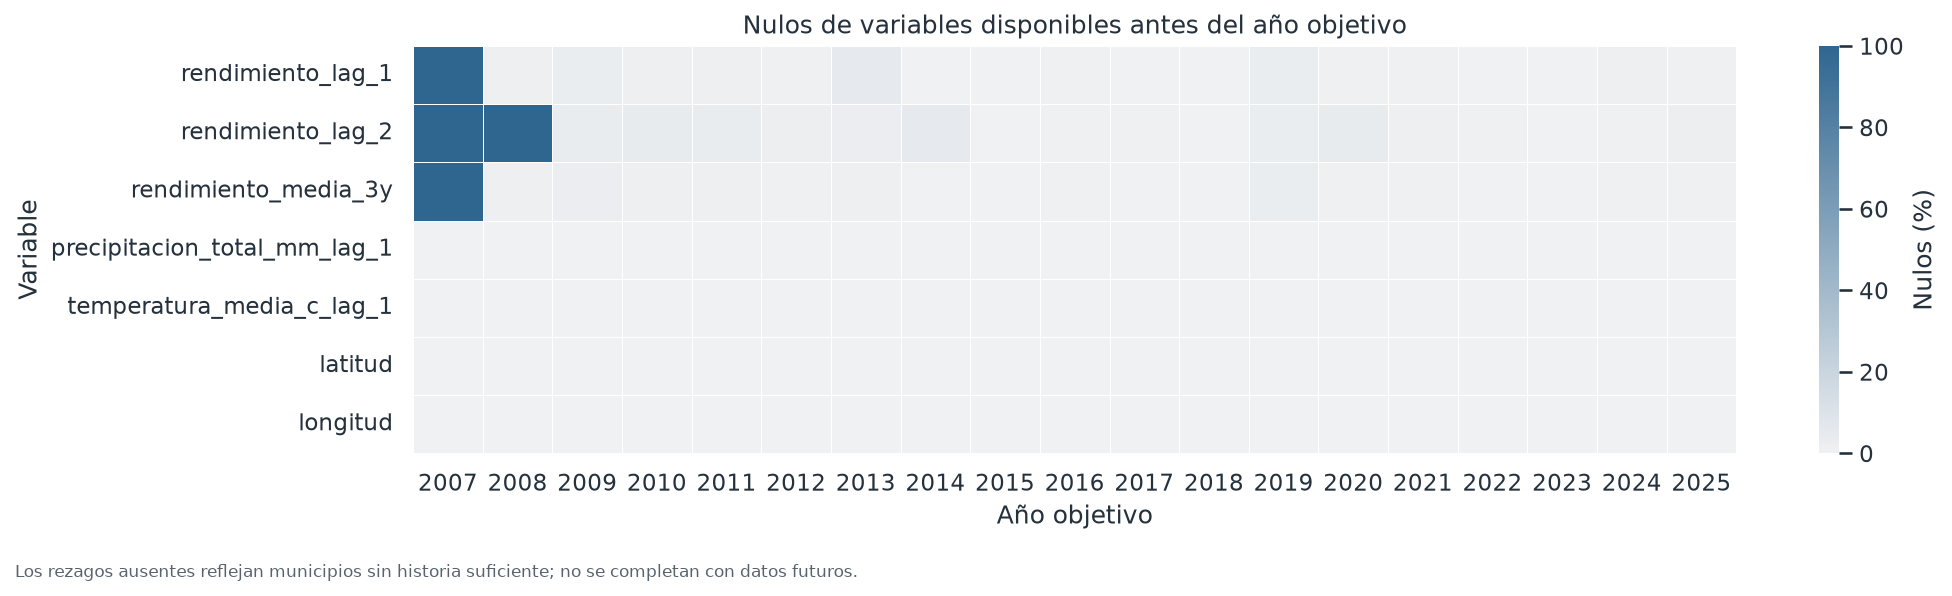

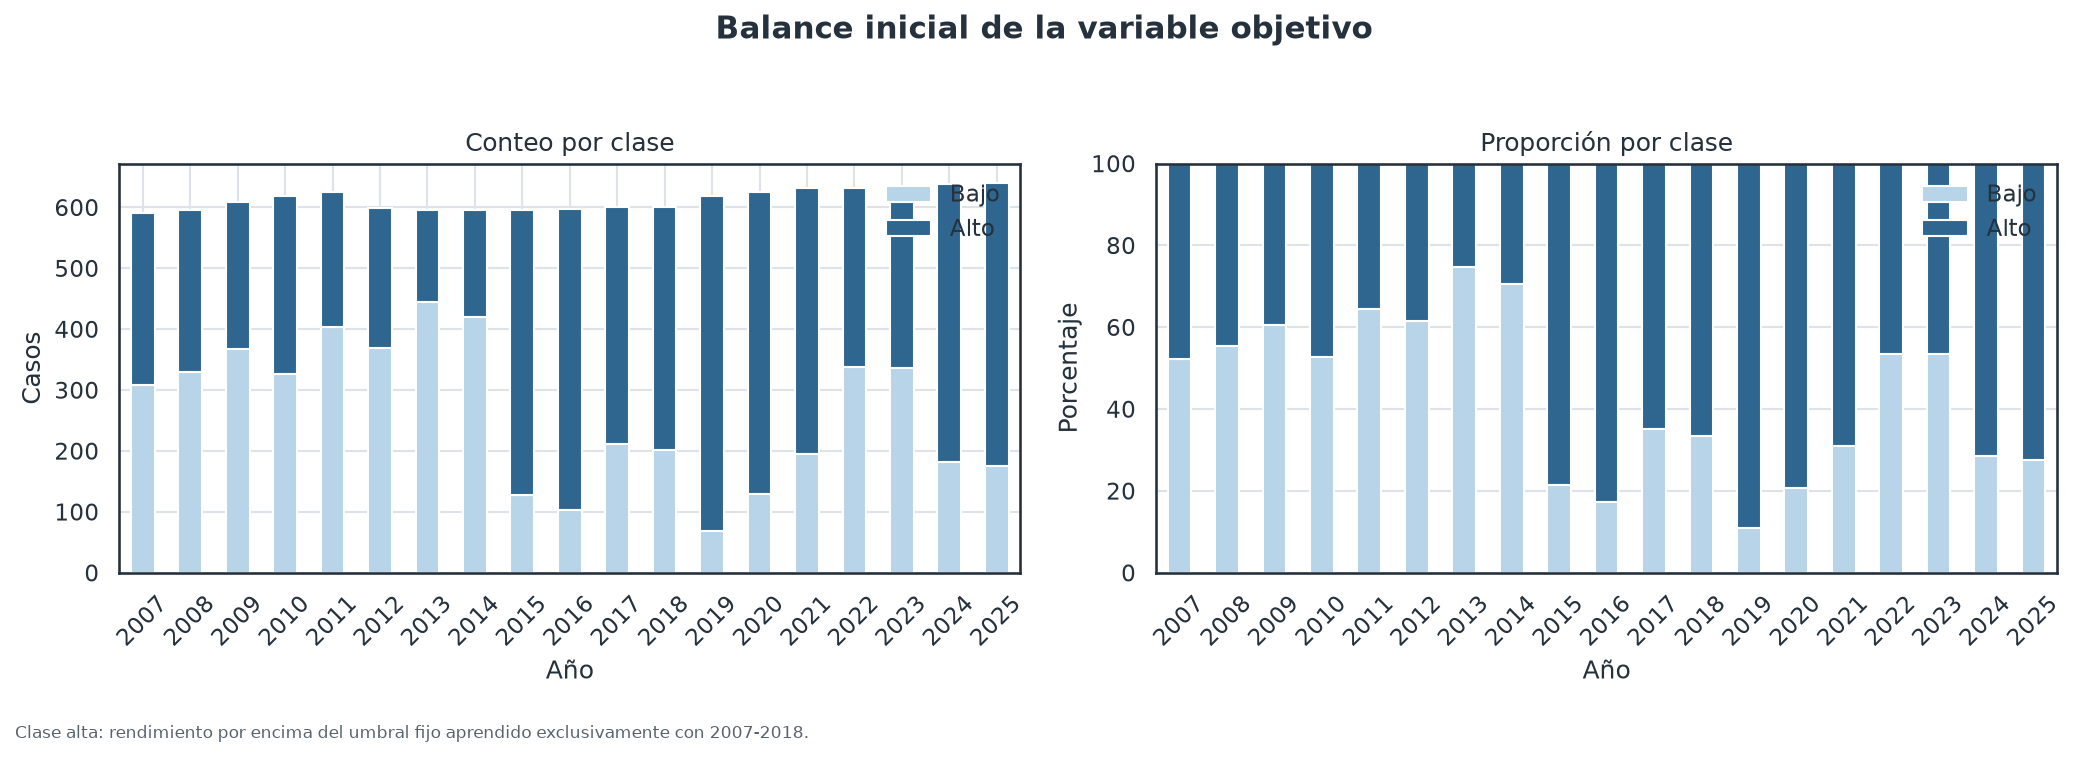

In [7]:
for figure in [
    "01_cobertura_fuentes_anual.png",
    "02_distribucion_rendimiento_inicial.png",
    "03_boxplot_rendimiento_anual.png",
    "04_mapa_nulos_cobertura.png",
    "05_balance_clases_anual.png",
]:
    display(Image(filename=str(OUT / figure)))

## 7. Variables point-in-time y ausencia de fuga temporal

Para el año `t` se usan rezagos exactos `t-1`, `t-2`, `t-3`, resúmenes históricos de 3 y 5 años y promedios acumulativos de municipio, departamento y país. Ninguna variable usa el resultado de `t`.

In [8]:
provenance = mart.query("anio >= 2019").groupby("anio").agg(
    max_eva_feature_year=("max_eva_feature_year", "max"),
    max_climate_feature_year=("max_climate_feature_year", "max"),
    feature_cutoff_year=("feature_cutoff_year", "max"),
)
assert (provenance.max_eva_feature_year < provenance.index).all()
assert (provenance.max_climate_feature_year < provenance.index).all()
assert (provenance.feature_cutoff_year < provenance.index).all()
display(provenance)

,max_eva_feature_year,max_climate_feature_year,feature_cutoff_year
anio,,,
2019,2018.0,2018,2018
2020,2019.0,2019,2019
2021,2020.0,2020,2020
2022,2021.0,2021,2021
2023,2022.0,2022,2022
2024,2023.0,2023,2023
2025,2024.0,2024,2024


## 8. Clima y geografía disponibles antes del objetivo

El clima de cada predicción corresponde al año anterior y se asigna desde la grilla NASA POWER más cercana al centroide municipal. La distancia de grilla queda como variable y advertencia.

In [9]:
climate = mart.groupby("anio").agg(
    cobertura_clima_pct=("climate_available", lambda value: 100 * value.mean()),
    distancia_mediana_grados=("distancia_grilla_grados", "median"),
    precipitacion_mediana_mm=("precipitacion_total_mm_lag_1", "median"),
    temperatura_mediana_c=("temperatura_media_c_lag_1", "median"),
)
display(climate.round(3))

,cobertura_clima_pct,distancia_mediana_grados,precipitacion_mediana_mm,temperatura_mediana_c
anio,,,,
2007,100.0,0.216,1197.805,18.975
2008,100.0,0.217,1072.270,19.527
2009,100.0,0.218,1079.720,19.330
2010,100.0,0.217,1213.400,19.418
2011,100.0,0.216,1970.050,19.277
2012,100.0,0.215,2068.890,18.233
2013,100.0,0.216,1654.280,18.628
2014,100.0,0.216,1767.480,19.030
2015,100.0,0.216,1517.130,19.352


## 9. Desarrollo cronológico y sellado de 2025

La comparación de algoritmos usa exclusivamente folds externos 2019-2024. El algoritmo y su umbral se congelan antes de consultar las etiquetas de 2025; sólo después se abre el holdout final.

In [10]:
development_mart = mart.query("anio <= 2024").copy()
holdout_2025_sealed = mart.query("anio == 2025").copy()
development_predictions_saved = pd.read_csv(OUT / "predicciones_todos_modelos_2019_2024.csv")
assert development_mart.anio.max() == 2024
assert development_predictions_saved.anio.max() == 2024
assert (development_predictions_saved.train_max_year < development_predictions_saved.anio).all()
assert (development_predictions_saved.threshold_source_max_year < development_predictions_saved.anio).all()
print({
    "desarrollo_hasta": int(development_mart.anio.max()),
    "holdout_2025_sellado": len(holdout_2025_sealed),
    "selección_sin_ver_2025": True,
})

{'desarrollo_hasta': 2024, 'holdout_2025_sellado': 640, 'selección_sin_ver_2025': True}


## 10. SMOTENC sólo dentro del entrenamiento

SMOTENC respeta las dos columnas categóricas y genera filas sintéticas únicamente en el bloque de entrenamiento. Validación y holdout mantienen su distribución real. El balance 5.799/5.799 no describe 2025 ni aumenta artificialmente su número de aciertos.

,etapa,clase,casos,fold_entrenamiento_hasta
0,Antes,Bajo,4471,2024
1,Antes,Alto,5799,2024
2,Después,Bajo,5799,2024
3,Después,Alto,5799,2024


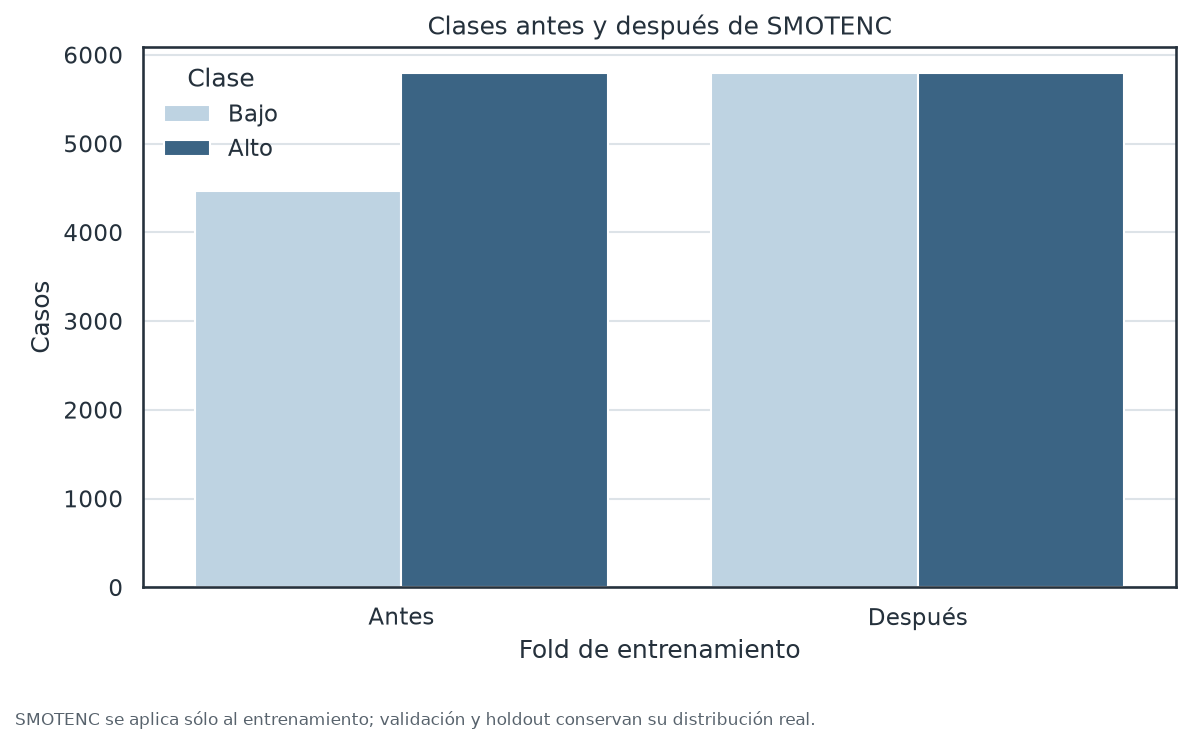

In [11]:
display(smote_balance)
assert smote_balance.query("etapa == 'Después'").casos.nunique() == 1
assert smote_balance.query("etapa == 'Antes'").casos.sum() == len(eligible_train)
display(Image(filename=str(OUT / "06_balance_smotenc.png")))

## 11. Backtesting walk-forward 2019-2024

Cada año se entrena con todos los años anteriores. Se comparan mayoría, persistencia del último año, regresión logística L2, regresión logística L2 + SMOTENC, gradient boosting, random forest y CatBoost poco profundo.

In [12]:
if RETRAIN_MODELS:
    development_result = walk_forward_backtest(
        mart,
        model_names=PRESENTATION_MODELS,
        years=range(2019, 2025),
        threshold_history_years=(2016, 2017, 2018),
    )
    development_predictions = development_result["predictions"]
    development_metrics = development_result["annual_metrics"]
    model_summary = development_result["model_summary"]
else:
    development_predictions = development_predictions_saved
    development_metrics = pd.read_csv(OUT / "metricas_anuales_todos_modelos.csv").query("anio <= 2024")
    model_summary = pd.read_csv(OUT / "resumen_modelos.csv")

assert development_predictions.anio.max() == 2024
assert (development_predictions.train_max_year < development_predictions.anio).all()
assert (development_predictions.threshold_source_max_year < development_predictions.anio).all()
display(model_summary.round(4))

,model,worst_joint_score,mean_joint_score,mean_mcc,mean_kappa,mean_weighted_precision,complexity
0,logistic_smotenc,0.0766,0.2803,0.3321,0.2803,0.7759,4
1,lag1,0.0712,0.3567,0.3841,0.3567,0.7847,1
2,logistic_plain,0.0645,0.2610,0.3128,0.2610,0.7724,2
3,hist_plain,0.0000,0.2397,0.2745,0.2397,0.7454,5
4,catboost_plain,0.0000,0.2377,0.2722,0.2377,0.7420,8
5,random_forest,0.0000,0.2164,0.2543,0.2164,0.7375,7
6,majority,0.0000,0.0000,0.0000,0.0000,0.4771,0


## 12. Selección del modelo sin usar 2025

La regla maximiza primero el peor `min(MCC, Kappa)` anual del desarrollo; después considera el promedio, la precisión ponderada y la simplicidad. Ganó `logistic_smotenc` por un margen pequeño en el peor año, no porque hubiera alcanzado 0,85.

{
  "selected_without_2025": true,
  "development_years": [
    2019,
    2020,
    2021,
    2022,
    2023,
    2024
  ],
  "winner": "logistic_smotenc",
  "recipe": {
    "name": "logistic_smotenc",
    "decision_threshold": 0.5499999999999999
  },
  "selection_rule": "maximizar el peor min(MCC, Kappa) anual; luego promedio, precisión ponderada y simplicidad"
}


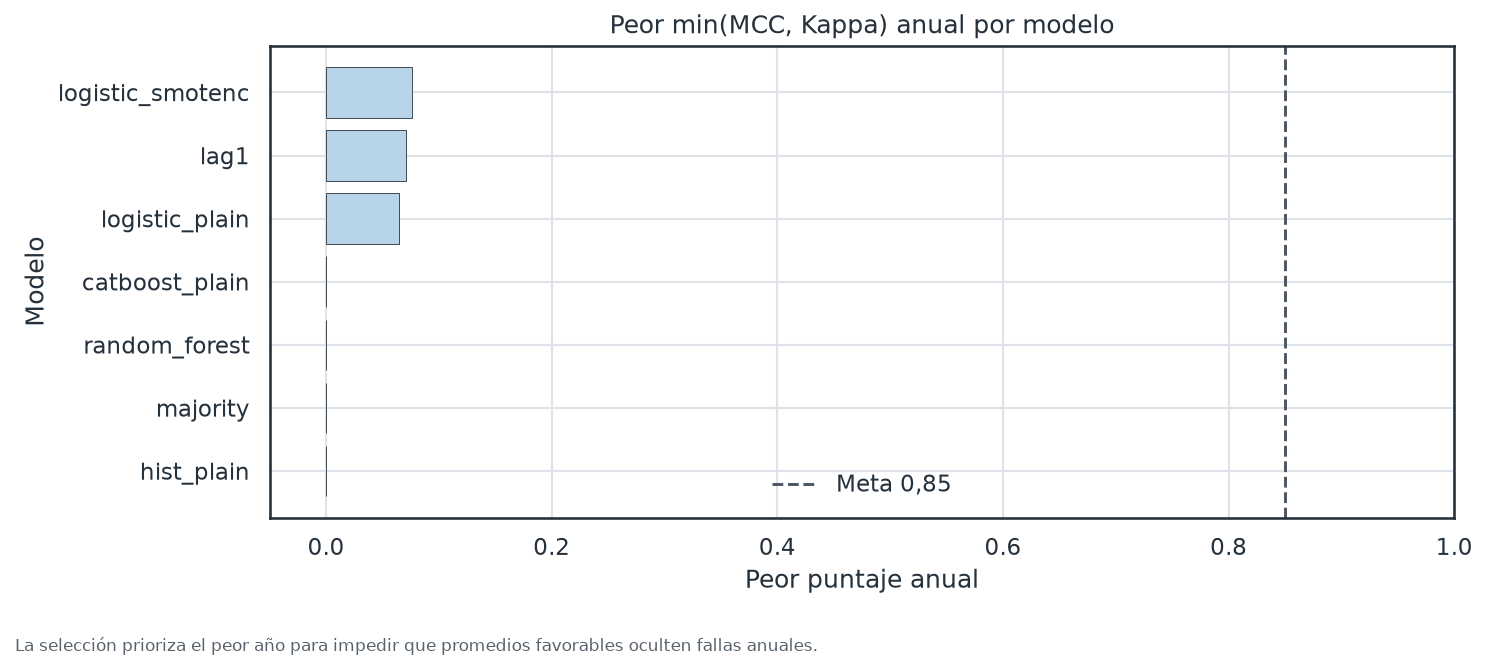

In [13]:
if RETRAIN_MODELS:
    frozen = {
        "selected_without_2025": True,
        "winner": development_result["winner"],
        "recipe": development_result["recipe"].to_dict(),
    }
else:
    frozen = json.loads((OUT / "recipe_frozen_before_2025.json").read_text(encoding="utf-8"))
assert frozen["selected_without_2025"] is True
print(json.dumps(frozen, ensure_ascii=False, indent=2))
display(Image(filename=str(OUT / "14_peor_resultado_anual_modelos.png")))

## 13. Métricas bajo el formato de WEKA

Se reportan TP Rate, FP Rate, Precision, Recall, F-Measure, MCC, ROC Area, PRC Area y soporte por clase. La “Precision” resumen de WEKA es el promedio ponderado por soporte; no equivale a MCC, Kappa ni necesariamente a accuracy.

,model,anio,TP Rate,FP Rate,Precision,Recall,F-Measure,MCC,ROC Area,PRC Area,Support,Class
72,logistic_smotenc,2019,0.7619,0.5382,0.1424,0.7619,0.2400,0.1382,0.6360,0.1864,63,Rendimiento bajo
73,logistic_smotenc,2019,0.4618,0.2381,0.9430,0.4618,0.6200,0.1382,0.6360,0.9364,537,Rendimiento alto
74,logistic_smotenc,2019,0.4933,0.2696,0.8589,0.4933,0.5801,0.1382,0.6360,0.8577,600,Weighted Avg.
75,logistic_smotenc,2020,0.1732,0.0163,0.7333,0.1732,0.2803,0.2952,0.7101,0.4893,127,Rendimiento bajo
76,logistic_smotenc,2020,0.9837,0.8268,0.8217,0.9837,0.8955,0.2952,0.7101,0.8756,492,Rendimiento alto
77,logistic_smotenc,2020,0.8174,0.6605,0.8036,0.8174,0.7692,0.2952,0.7101,0.7964,619,Weighted Avg.
78,logistic_smotenc,2021,0.2434,0.0940,0.5287,0.2434,0.3333,0.1982,0.7294,0.4858,189,Rendimiento bajo
79,logistic_smotenc,2021,0.9060,0.7566,0.7342,0.9060,0.8111,0.1982,0.7294,0.8591,436,Rendimiento alto
80,logistic_smotenc,2021,0.7056,0.5563,0.6721,0.7056,0.6666,0.1982,0.7294,0.7462,625,Weighted Avg.
81,logistic_smotenc,2022,0.2396,0.0307,0.9000,0.2396,0.3785,0.2980,0.7907,0.8082,338,Rendimiento bajo


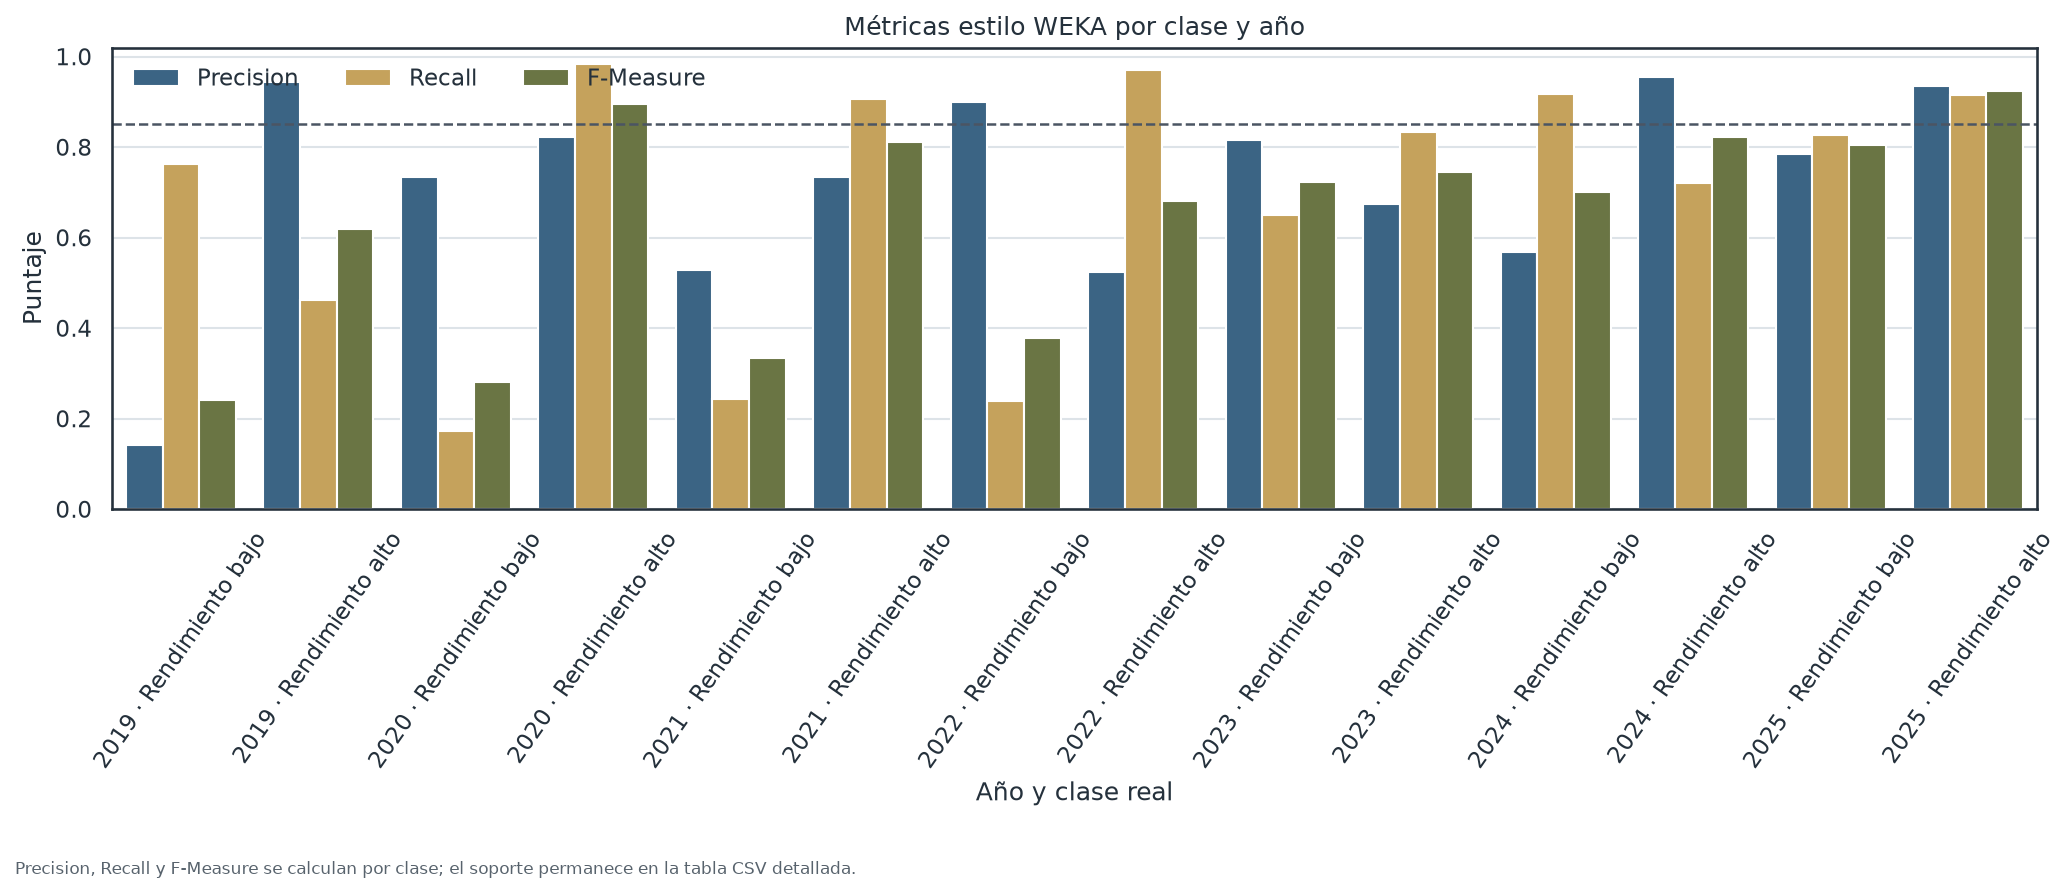

In [14]:
weka_development = pd.read_csv(OUT / "metricas_weka_todos_modelos.csv").query("anio <= 2024")
winner_name = frozen["winner"]
weka_winner = weka_development.query("model == @winner_name")
display(weka_winner.round(4))
display(Image(filename=str(OUT / "10_metricas_weka_clases.png")))

## 14. Matrices de confusión del desarrollo 2019-2024

Estas matrices muestran que el buen resultado de 2025 no fue estable en años anteriores. Cada matriz se calcula por separado y suma exactamente el número de municipios evaluados ese año.

In [15]:
winner_development = development_predictions.query("model == @winner_name")
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
matrix_rows = []
for ax, (year, group) in zip(axes.flat, winner_development.groupby("anio")):
    matrix = confusion_matrix(group.y_true, group.y_pred, labels=[0, 1])
    year_tn, year_fp, year_fn, year_tp = matrix.ravel()
    matrix_rows.append({"anio": year, "tn": year_tn, "fp": year_fp, "fn": year_fn, "tp": year_tp, "n": len(group)})
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True, ax=ax)
    ax.set(title=f"{year} (n={len(group)})", xlabel="Predicción", ylabel="Real")
    ax.set_xticklabels(["Bajo", "Alto"])
    ax.set_yticklabels(["Bajo", "Alto"], rotation=0)
plt.tight_layout()
plt.show()
display(pd.DataFrame(matrix_rows))

C:\Users\Visitante\AppData\Local\Temp\ipykernel_28468\483136139.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,anio,tn,fp,fn,tp,n
0,2019,48,15,289,248,600
1,2020,22,105,8,484,619
2,2021,46,143,41,395,625
3,2022,81,257,9,284,631
4,2023,218,118,49,243,628
5,2024,164,15,125,324,628


## 15. Errores, calibración, cambios de clase y explicabilidad

Se distingue el desempeño cuando la clase cambia respecto a `t-1`, porque la persistencia es un baseline fuerte. La importancia por permutación mide contribución predictiva, no causalidad.

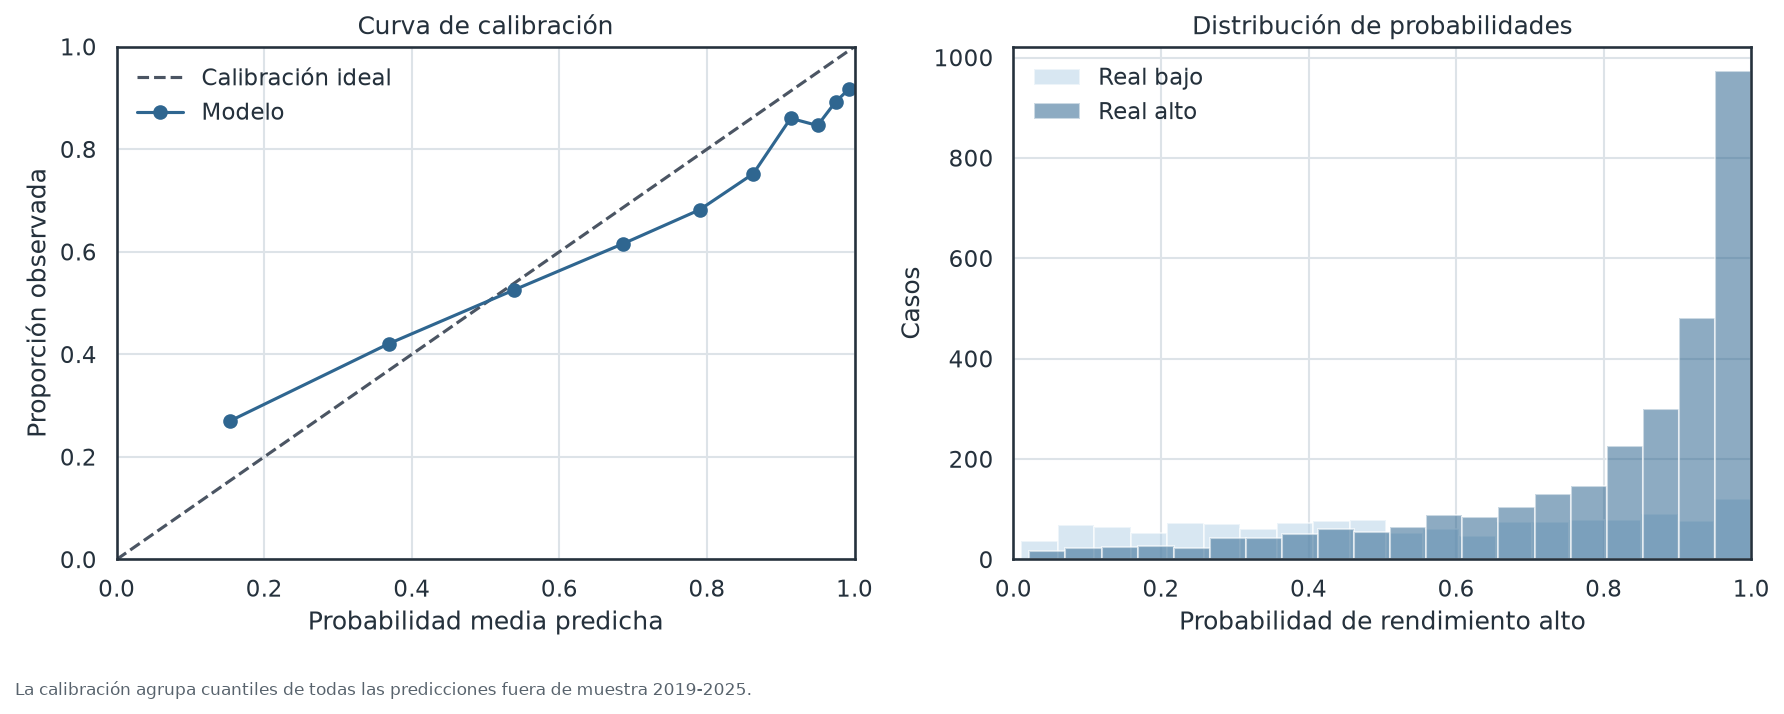

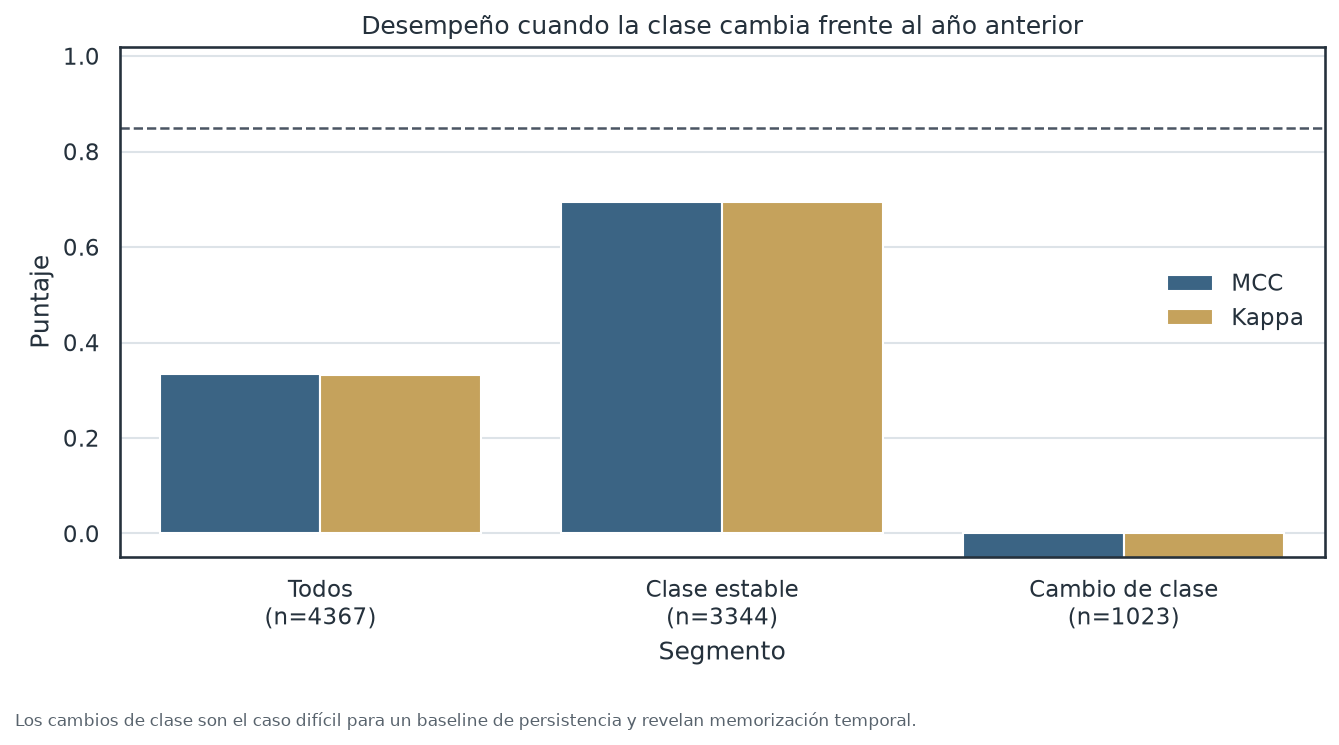

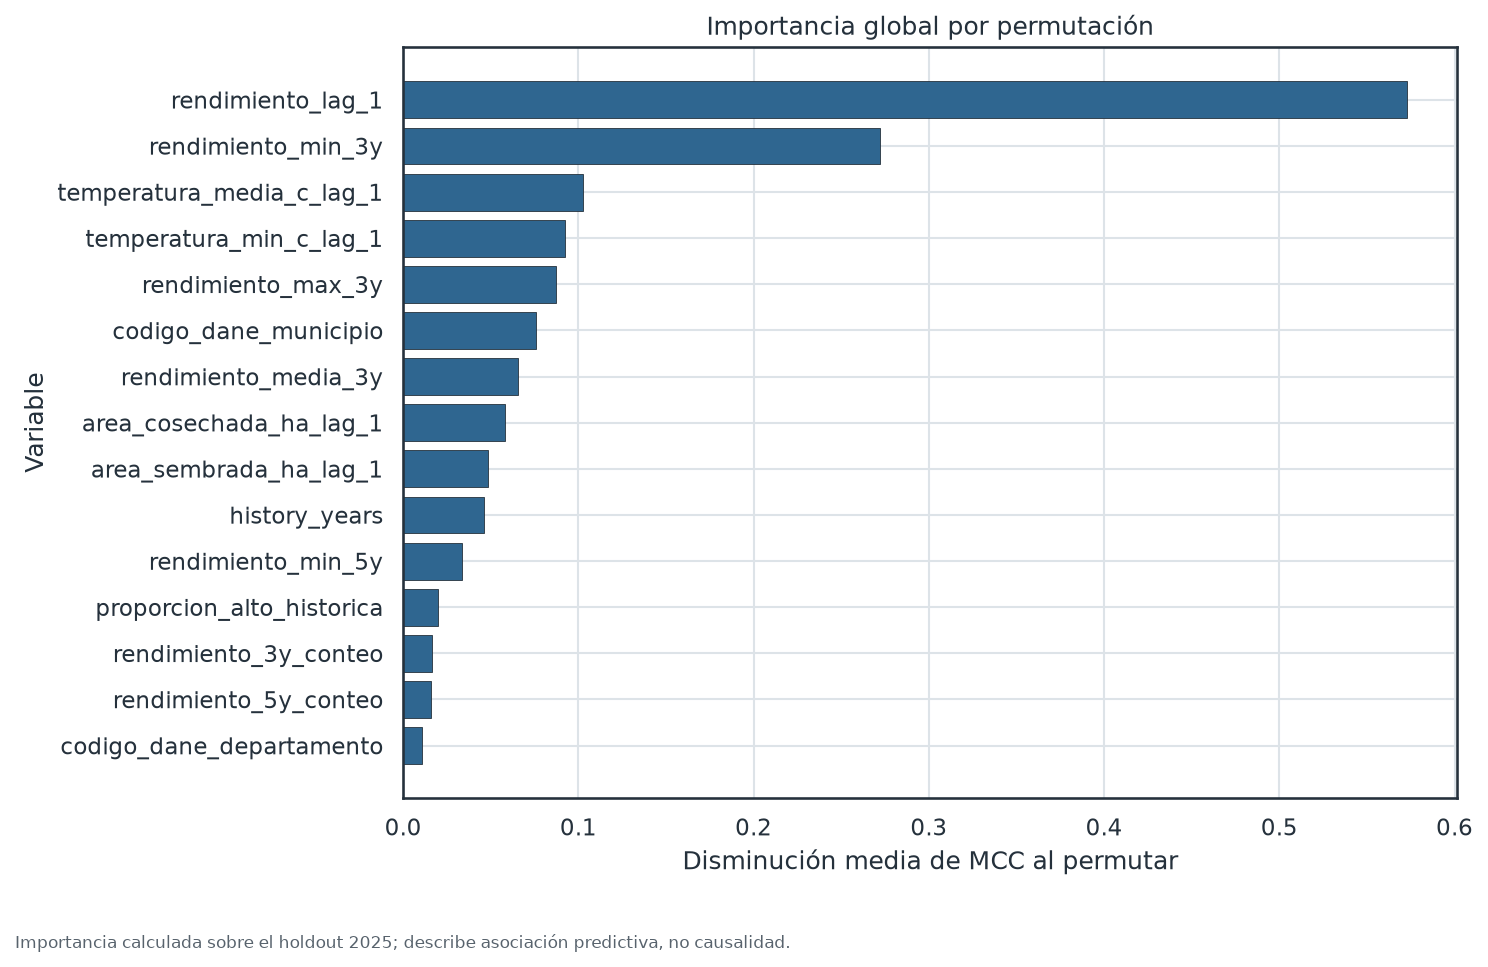

,feature,importance,importance_std
0,rendimiento_lag_1,0.5730,0.0366
1,rendimiento_min_3y,0.2719,0.0229
2,temperatura_media_c_lag_1,0.1025,0.0144
3,temperatura_min_c_lag_1,0.0923,0.0200
4,rendimiento_max_3y,0.0870,0.0345
5,codigo_dane_municipio,0.0758,0.0124
6,rendimiento_media_3y,0.0658,0.0224
7,area_cosechada_ha_lag_1,0.0583,0.0096
8,area_sembrada_ha_lag_1,0.0486,0.0239
9,history_years,0.0461,0.0122


In [16]:
for figure in [
    "11_calibracion_probabilidades.png",
    "12_desempeno_cambios_clase.png",
    "13_importancia_variables.png",
]:
    display(Image(filename=str(OUT / figure)))
importance = pd.read_csv(OUT / "importancia_variables.csv")
display(importance.head(15).round(4))

## 16. Receta congelada antes de abrir 2025

La receta final es regresión logística L2, preprocesamiento de variables categóricas, SMOTENC dentro de train y umbral de probabilidad 0,55. El objeto serializado fue ajustado con años 2008-2024.

In [17]:
recipe = ModelRecipe(**frozen["recipe"])
print({
    "modelo_congelado": recipe.name,
    "umbral_congelado": recipe.decision_threshold,
    "último_año_de_entrenamiento": int(final_predictions.train_max_year.max()),
})
assert recipe.name == winner_name
assert final_predictions.train_max_year.max() == 2024

{'modelo_congelado': 'logistic_smotenc', 'umbral_congelado': 0.5499999999999999, 'último_año_de_entrenamiento': 2024}


## 17. Fuentes, armonización y reproducción del holdout

EVA histórica 2007-2018 y EVA reciente 2019-2025 provienen del Ministerio de Agricultura / Datos Abiertos Colombia; DIVIPOLA 2025 del DANE; el clima mensual 2006-2024 de NASA POWER MERRA-2. Las descargas se congelan con URL, fecha, filas y SHA-256.

Los duplicados de rendimiento se reconstruyen como `suma(producción) / suma(área cosechada)` y las uniones geográficas usan el código DIVIPOLA de cinco dígitos.

In [18]:
source_manifest = json.loads((OUT / "source_manifest.json").read_text(encoding="utf-8"))
audit = audit_point_in_time(mart)
assert mart[["codigo_dane_municipio", "anio"]].duplicated().sum() == 0
assert mart["codigo_dane_municipio"].str.fullmatch(r"\d{5}").all()
display(pd.Series({key: value for key, value in audit.items() if key != "missing_percent"}, name="auditoría").to_frame())
display(pd.DataFrame({
    "manifiesto": list(source_manifest),
    "contenido": [type(value).__name__ for value in source_manifest.values()],
}))

if RETRAIN_MODELS:
    reproduced_predictions, reproduced_estimator = evaluate_final_holdout(mart, recipe, year=2025)
    reproduced_metrics, reproduced_weka = annual_metrics(reproduced_predictions)
    assert np.array_equal(reproduced_predictions.y_pred, final_predictions.y_pred)
    display(reproduced_metrics.round(6))
else:
    print("Modo verificado: se cargan predicciones congeladas. Use RETRAIN_MODELS=True para repetir ajuste y holdout.")

,auditoría
rows,11631.0
municipalities,664.0
year_min,2007.0
year_max,2025.0
duplicate_keys,0.0
climate_coverage,1.0


,manifiesto,contenido
0,source_manifest,dict
1,nasa_power_manifest,dict


Modo verificado: se cargan predicciones congeladas. Use RETRAIN_MODELS=True para repetir ajuste y holdout.


## 18. Evidencia secundaria: otros años y baseline de persistencia

El 2025 fue el mejor año del modelo, pero no basta para afirmar estabilidad. En 2019-2024 MCC y Kappa fueron mucho menores. Además, en 2025 la regla simple “predecir la misma clase del año anterior” superó a la regresión logística; eso limita cualquier afirmación de valor productivo incremental.

,anio,instances,accuracy,weighted_precision,mcc,kappa,mcc_ci_low,mcc_ci_high,kappa_ci_low,kappa_ci_high,cumple_mcc_kappa_085
0,2019,600,0.4933,0.8589,0.1382,0.0766,0.0660,0.2074,0.0356,0.1197,False
1,2020,619,0.8174,0.8036,0.2952,0.2190,0.1930,0.3843,0.1301,0.3034,False
2,2021,625,0.7056,0.6721,0.1982,0.1763,0.1150,0.2768,0.0981,0.2489,False
3,2022,631,0.5784,0.7259,0.2980,0.1978,0.2351,0.3544,0.1487,0.2482,False
4,2023,628,0.7341,0.7498,0.4853,0.4737,0.4180,0.5479,0.4052,0.5396,False
5,2024,628,0.7771,0.8451,0.5777,0.5383,0.5223,0.6297,0.4800,0.5952,False
6,2025,636,0.8915,0.8936,0.7309,0.7305,0.6654,0.7908,0.6653,0.7901,False


,método,precisión_ponderada,MCC,Kappa
0,Regresión L2 + SMOTENC,0.893607,0.730907,0.730456
1,Persistencia: repetir clase 2024,0.958666,0.895079,0.894526


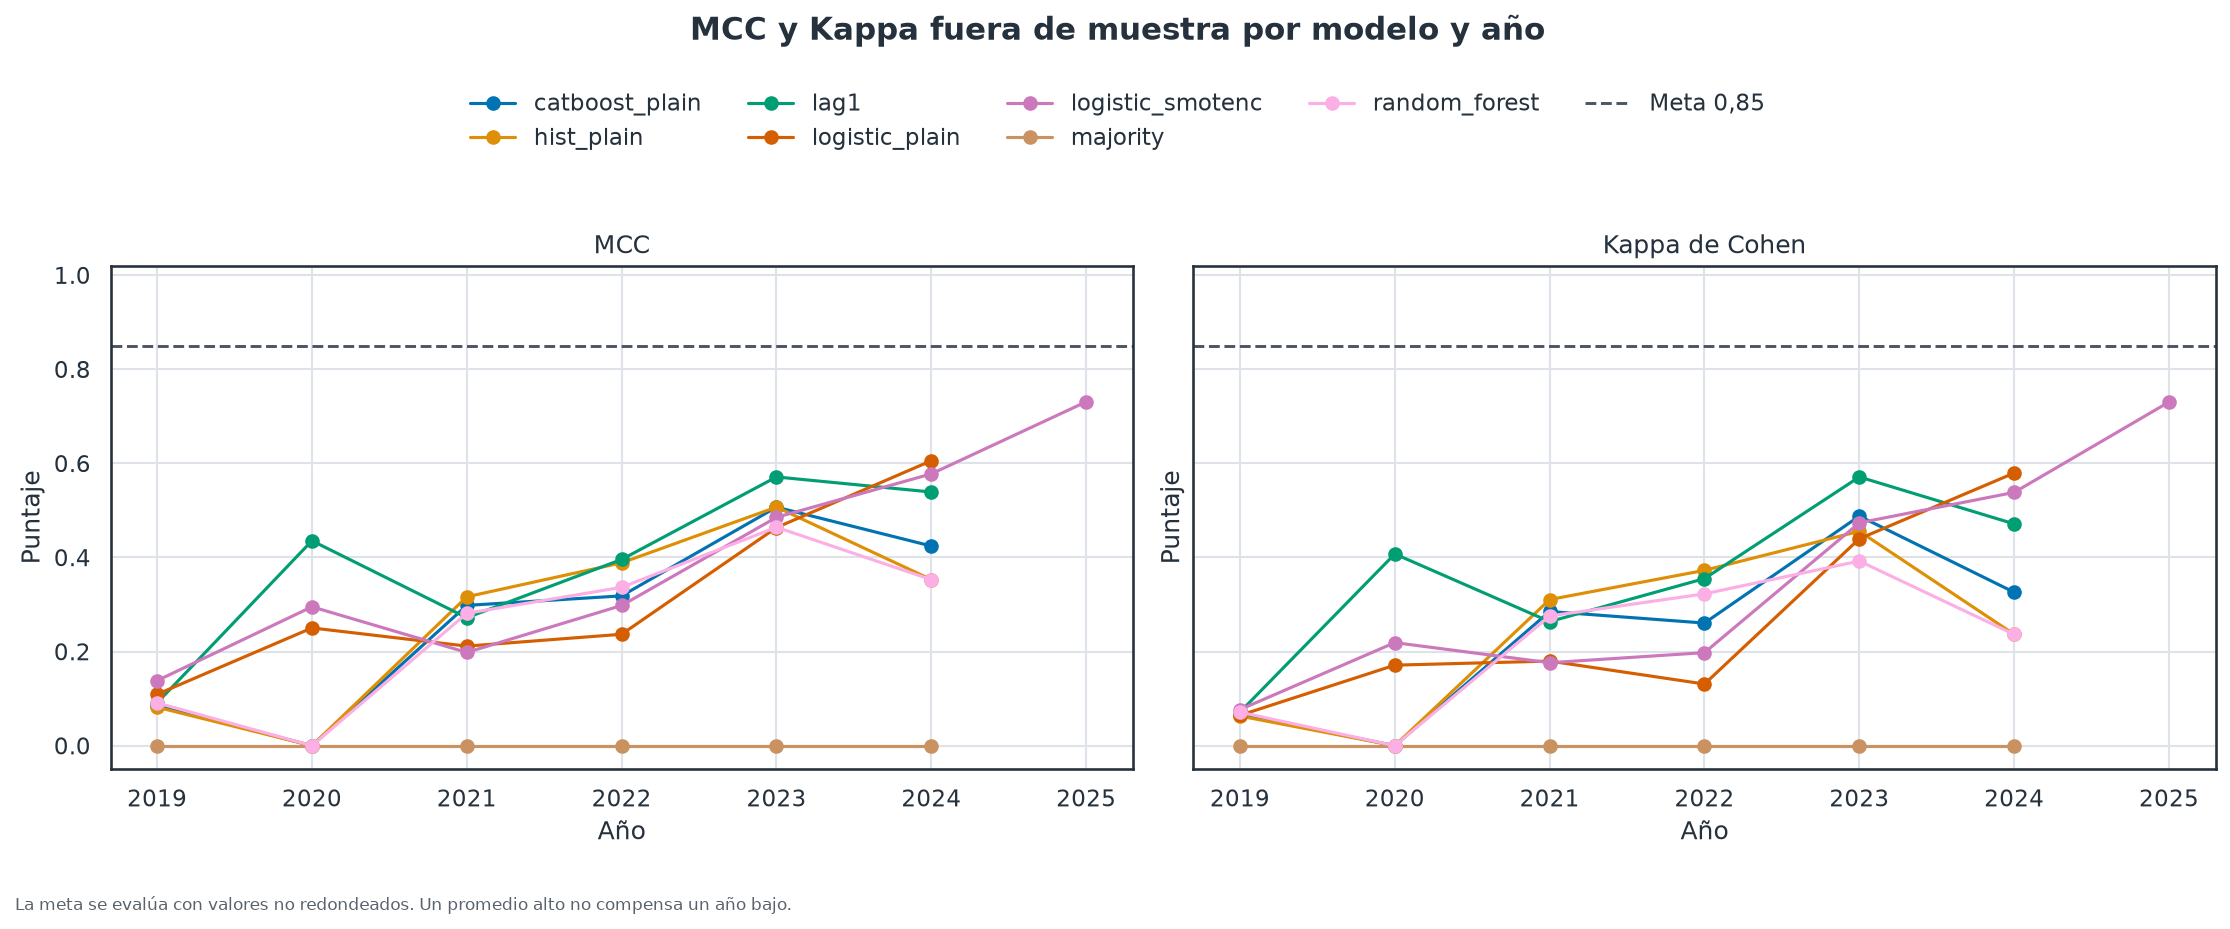

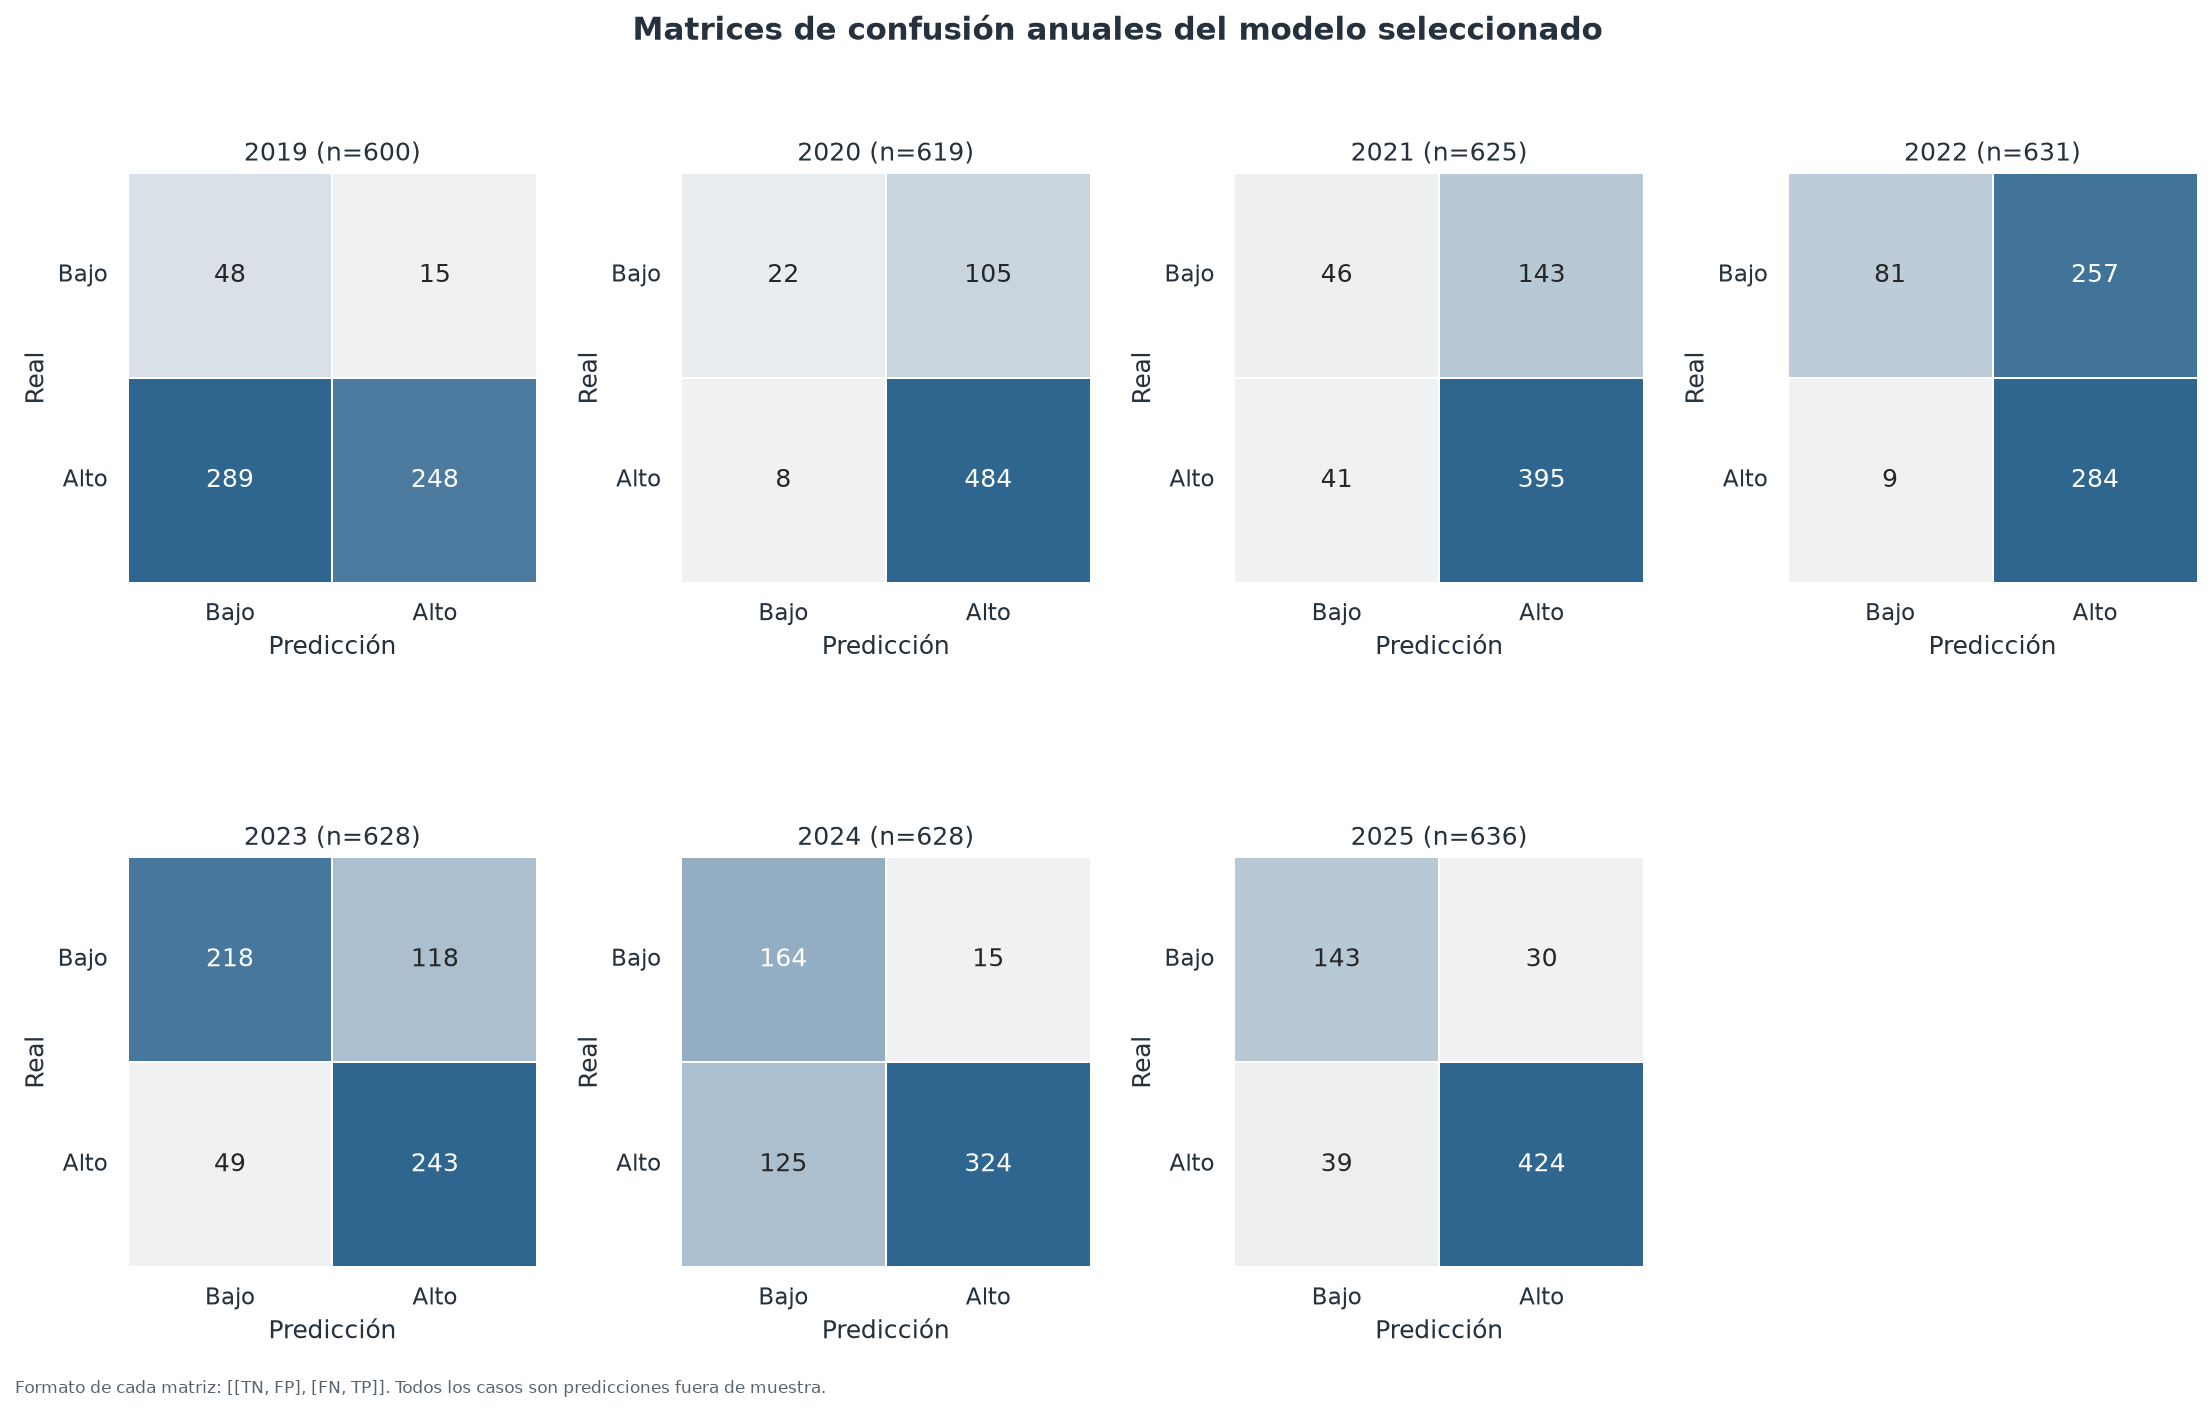

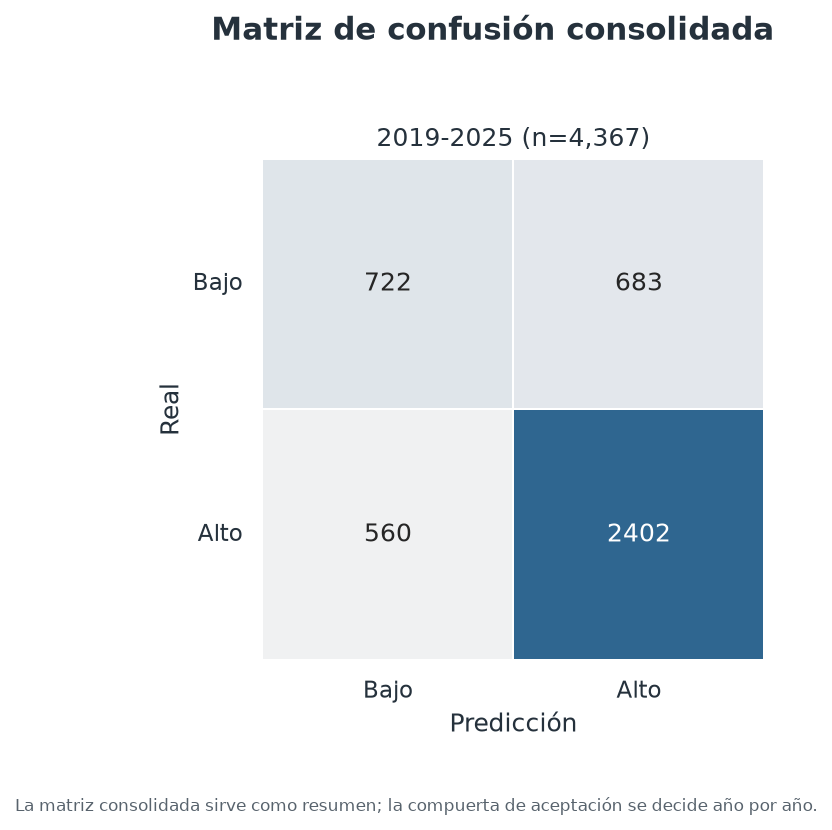

In [19]:
winner_metrics = pd.read_csv(OUT / "metricas_anuales_modelo_seleccionado.csv")
winner_metrics["cumple_mcc_kappa_085"] = (winner_metrics.mcc >= 0.85) & (winner_metrics.kappa >= 0.85)
display(winner_metrics[[
    "anio", "instances", "accuracy", "weighted_precision", "mcc", "kappa",
    "mcc_ci_low", "mcc_ci_high", "kappa_ci_low", "kappa_ci_high", "cumple_mcc_kappa_085",
]].round(4))

persistence_pred_2025 = final_predictions.clase_lag_1.astype(int).to_numpy()
persistence_2025 = pd.DataFrame({
    "método": ["Regresión L2 + SMOTENC", "Persistencia: repetir clase 2024"],
    "precisión_ponderada": [
        weighted_precision_2025,
        precision_score(y_true_2025, persistence_pred_2025, average="weighted", zero_division=0),
    ],
    "MCC": [mcc_2025, matthews_corrcoef(y_true_2025, persistence_pred_2025)],
    "Kappa": [kappa_2025, cohen_kappa_score(y_true_2025, persistence_pred_2025)],
})
display(persistence_2025.round(6))
display(Image(filename=str(OUT / "07_metricas_mcc_kappa_anuales.png")))
display(Image(filename=str(OUT / "08_matrices_confusion_2019_2025.png")))
display(Image(filename=str(OUT / "09_matriz_confusion_consolidada.png")))

## 19. Compuerta estricta y conclusión crítica

El modelo sólo puede llamarse candidato a producción si todos los años superan MCC y Kappa de 0,85 y mejora el peor año de persistencia al menos 0,02. Una precisión WEKA superior a 85% en 2025 no reemplaza esas condiciones.

In [20]:
gate = manifest["gate"]
display(pd.DataFrame({
    "año": winner_metrics.anio,
    "MCC": winner_metrics.mcc,
    "Kappa": winner_metrics.kappa,
    "estado": np.where((winner_metrics.mcc >= 0.85) & (winner_metrics.kappa >= 0.85), "CUMPLE", "NO CUMPLE"),
}).round(4))
print("ESTADO FINAL:", manifest["status"])
for failure in gate["failed_checks"]:
    print("-", failure)
assert manifest["status"] == "target_not_met"

,año,MCC,Kappa,estado
0,2019,0.1382,0.0766,NO CUMPLE
1,2020,0.2952,0.2190,NO CUMPLE
2,2021,0.1982,0.1763,NO CUMPLE
3,2022,0.2980,0.1978,NO CUMPLE
4,2023,0.4853,0.4737,NO CUMPLE
5,2024,0.5777,0.5383,NO CUMPLE
6,2025,0.7309,0.7305,NO CUMPLE


ESTADO FINAL: target_not_met
- MCC o Kappa inferior a 0.85 en años: [2019, 2020, 2021, 2022, 2023, 2024, 2025].
- La mejora del peor año frente a persistencia es 0.0054, inferior a 0.02.


## 20. Artefactos, uso permitido y respuesta final

**Sí responde una pregunta medible:** clasificar el rendimiento municipal anual como bajo/alto usando únicamente historia previa. **No demuestra todavía utilidad productiva:** falla MCC/Kappa de 0,85 en todos los años y en 2025 no supera la persistencia.

Uso permitido: demostración académica, análisis exploratorio y priorización con revisión humana y advertencia visible. No debe usarse para decisiones automáticas, crédito, inversión ni para afirmar una precisión futura garantizada.

In [21]:
artifacts = sorted(path.name for path in OUT.iterdir() if path.is_file())
display(pd.DataFrame({"artefacto": artifacts}))
print(f"Modelo seleccionado: {manifest['winner']}")
print(f"Casos 2025: {n_2025}; aciertos: {correct_2025}; precisión WEKA: {weighted_precision_2025:.4%}")
print(f"MCC 2025: {mcc_2025:.6f}; Kappa 2025: {kappa_2025:.6f}")
print(f"Años que incumplen MCC/Kappa 0,85: {manifest['gate']['failed_years']}")
print("Conclusión: resultado 2025 reproducible y explicable, pero el prototipo NO está listo para producción.")

,artefacto
0,01_cobertura_fuentes_anual.png
1,02_distribucion_rendimiento_inicial.png
2,03_boxplot_rendimiento_anual.png
3,04_mapa_nulos_cobertura.png
4,05_balance_clases_anual.png
5,06_balance_smotenc.png
6,07_metricas_mcc_kappa_anuales.png
7,08_matrices_confusion_2019_2025.png
8,09_matriz_confusion_consolidada.png
9,10_metricas_weka_clases.png


Modelo seleccionado: logistic_smotenc
Casos 2025: 636; aciertos: 567; precisión WEKA: 89.3607%
MCC 2025: 0.730907; Kappa 2025: 0.730456
Años que incumplen MCC/Kappa 0,85: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
Conclusión: resultado 2025 reproducible y explicable, pero el prototipo NO está listo para producción.
